In [1]:
# Run this once to install libraries if needed
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

In [1]:
# Run this once to install libraries if needed
#!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Optional: XGBoost (install if not available)
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False
    print('XGBoost not installed. Run: pip install xgboost')

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [7]:
df = pd.read_csv(r"C:\Users\balam\Bike rental project\day.csv")
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [8]:
df.describe().round(2)

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.00,731.00,731.0,731.00,731.00,731.0,731.00,731.00,731.00,731.00,731.00,731.00,731.00,731.00,731.00
mean,366.00,2.50,0.5,6.52,0.03,3.0,0.68,1.40,0.50,0.47,0.63,0.19,848.18,3656.17,4504.35
std,211.17,1.11,0.5,3.45,0.17,2.0,0.47,0.54,0.18,0.16,0.14,0.08,686.62,1560.26,1937.21
min,1.00,1.00,0.0,1.00,0.00,0.0,0.00,1.00,0.06,0.08,0.00,0.02,2.00,20.00,22.00
25%,183.50,2.00,0.0,4.00,0.00,1.0,0.00,1.00,0.34,0.34,0.52,0.13,315.50,2497.00,3152.00
50%,366.00,3.00,1.0,7.00,0.00,3.0,1.00,1.00,0.50,0.49,0.63,0.18,713.00,3662.00,4548.00
75%,548.50,3.00,1.0,10.00,0.00,5.0,1.00,2.00,0.66,0.61,0.73,0.23,1096.00,4776.50,5956.00
max,731.00,4.00,1.0,12.00,1.00,6.0,1.00,3.00,0.86,0.84,0.97,0.51,3410.00,6946.00,8714.00


In [9]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df_clean = df.drop(columns=['instant', 'dteday', 'casual', 'registered'])

In [11]:
df_clean.shape

(731, 12)

In [12]:
df_clean.columns.tolist()

['season',
 'yr',
 'mnth',
 'holiday',
 'weekday',
 'workingday',
 'weathersit',
 'temp',
 'atemp',
 'hum',
 'windspeed',
 'cnt']

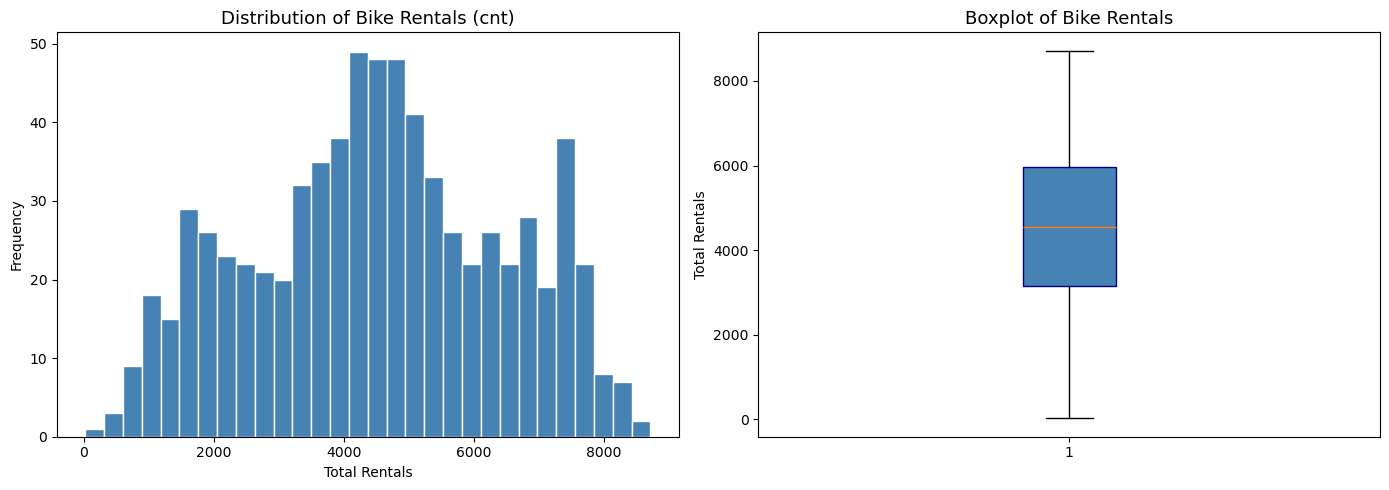

📌 Insight: cnt is roughly bell-shaped (slightly right-skewed). Most days have 4000–6000 rentals.


In [13]:
# 1. Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['cnt'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Bike Rentals (cnt)', fontsize=13)
axes[0].set_xlabel('Total Rentals')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df_clean['cnt'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot of Bike Rentals', fontsize=13)
axes[1].set_ylabel('Total Rentals')

plt.tight_layout()
plt.savefig('plot1_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('📌 Insight: cnt is roughly bell-shaped (slightly right-skewed). Most days have 4000–6000 rentals.')

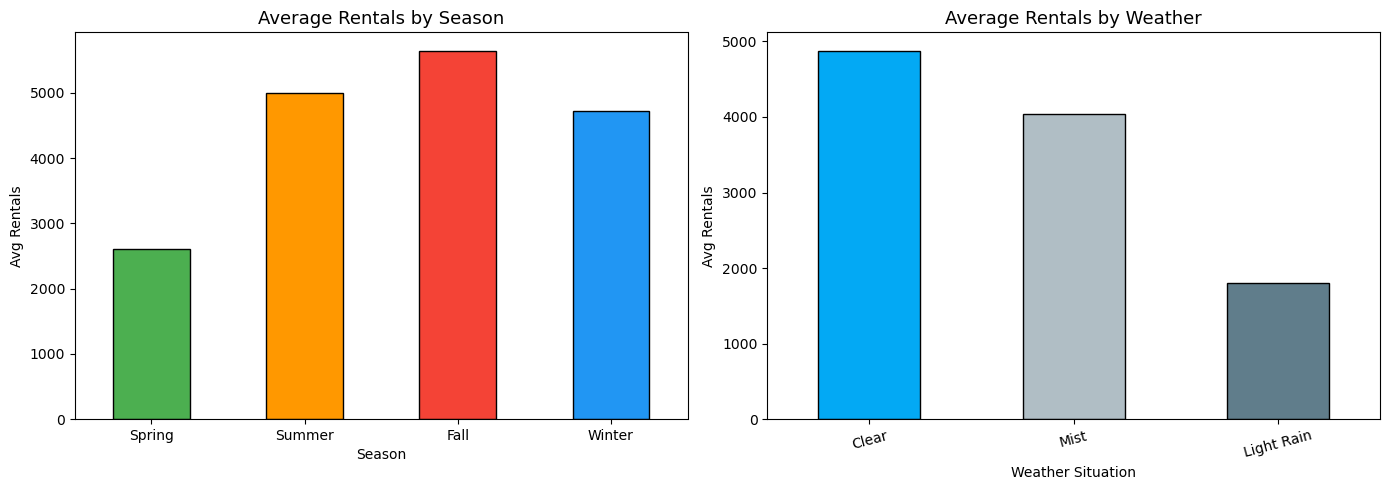

📌 Insight: Fall has the highest rentals; Spring the lowest. Clear weather = more rides!


In [14]:
# 2. Rentals by Season and Weather
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_map = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
season_avg = df_clean.groupby('season')['cnt'].mean().rename(index=season_map)
season_avg.plot(kind='bar', ax=axes[0], color=['#4CAF50','#FF9800','#F44336','#2196F3'], edgecolor='black')
axes[0].set_title('Average Rentals by Season', fontsize=13)
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Avg Rentals')
axes[0].tick_params(axis='x', rotation=0)

weather_map = {1:'Clear', 2:'Mist', 3:'Light Rain', 4:'Heavy Rain'}
weather_avg = df_clean.groupby('weathersit')['cnt'].mean().rename(index=weather_map)
weather_avg.plot(kind='bar', ax=axes[1], color=['#03A9F4','#B0BEC5','#607D8B','#37474F'], edgecolor='black')
axes[1].set_title('Average Rentals by Weather', fontsize=13)
axes[1].set_xlabel('Weather Situation')
axes[1].set_ylabel('Avg Rentals')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('plot2_season_weather.png', dpi=100, bbox_inches='tight')
plt.show()
print('📌 Insight: Fall has the highest rentals; Spring the lowest. Clear weather = more rides!')

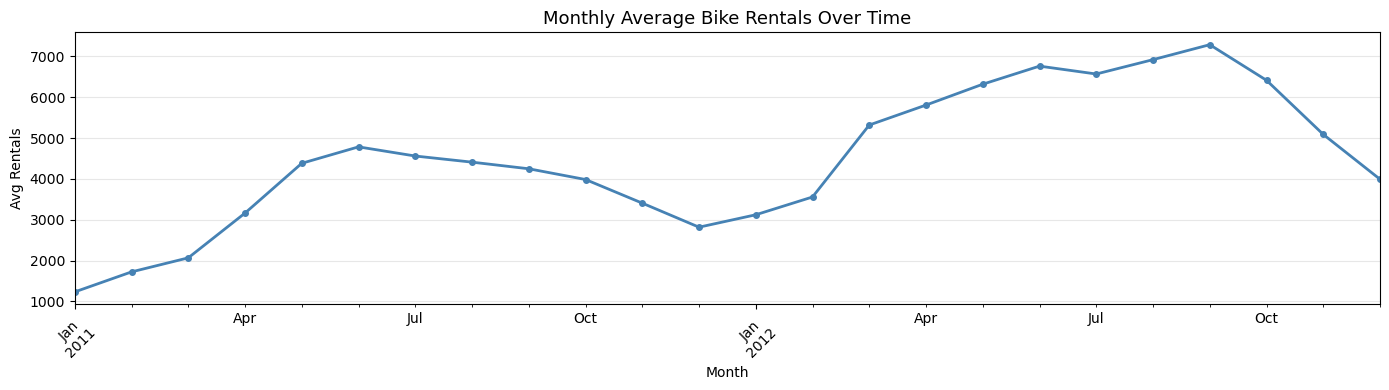

📌 Insight: Clear seasonality pattern — peak in summer/fall, dip in winter. Year-over-year growth visible!


In [15]:
# 3. Rentals over time (monthly trend)
df_trend = df.copy()
df_trend['month_label'] = pd.to_datetime(df_trend['dteday']).dt.to_period('M')
monthly = df_trend.groupby('month_label')['cnt'].mean()

plt.figure(figsize=(14, 4))
monthly.plot(color='steelblue', linewidth=2, marker='o', markersize=4)
plt.title('Monthly Average Bike Rentals Over Time', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Avg Rentals')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot3_trend.png', dpi=100, bbox_inches='tight')
plt.show()
print('📌 Insight: Clear seasonality pattern — peak in summer/fall, dip in winter. Year-over-year growth visible!')

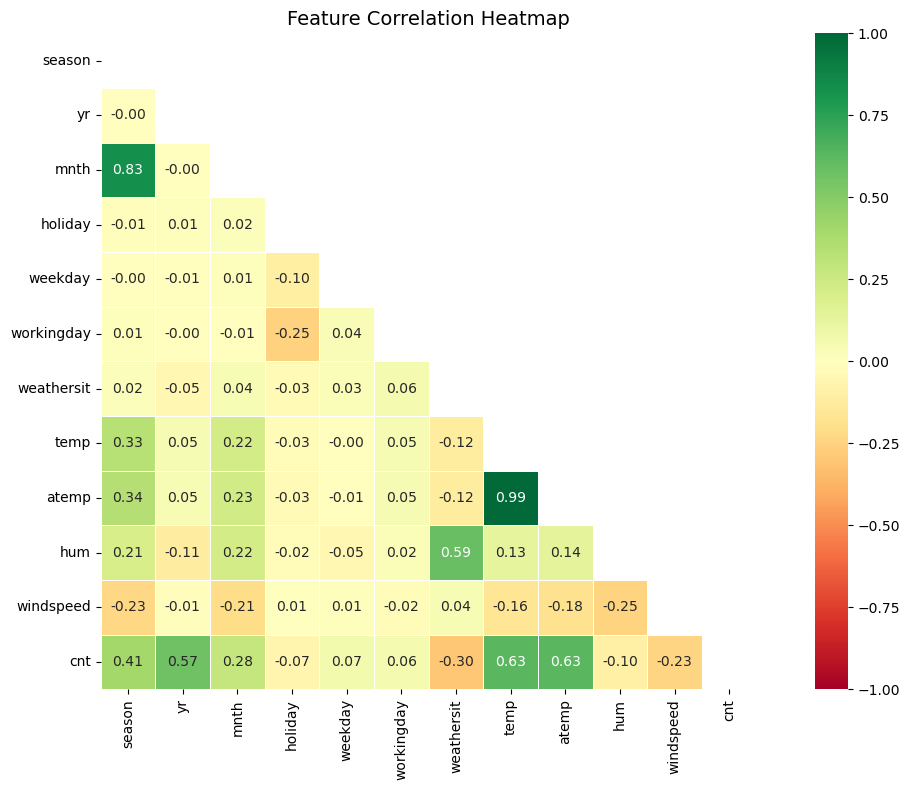

📌 Insight: temp & atemp have strong positive correlation with cnt (~0.63).
   hum and windspeed have weak negative correlation.
   temp and atemp are highly correlated (0.99) — multicollinearity risk!


In [16]:
# 4. Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, vmin=-1, vmax=1, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('plot4_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print('📌 Insight: temp & atemp have strong positive correlation with cnt (~0.63).')
print('   hum and windspeed have weak negative correlation.')
print('   temp and atemp are highly correlated (0.99) — multicollinearity risk!')

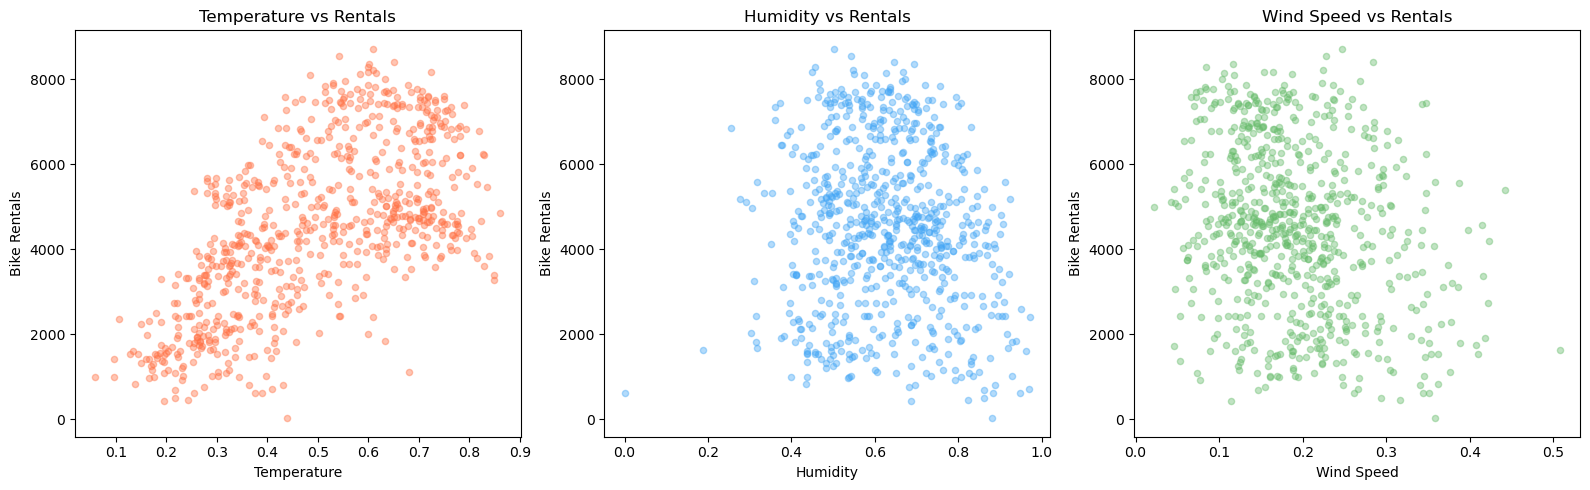

📌 Insight: Positive relationship with temperature. Higher humidity = slightly fewer rides.


In [17]:
# 5. Scatter: Temperature vs Rentals
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color, label in zip(axes,
    ['temp', 'hum', 'windspeed'],
    ['#FF7043', '#42A5F5', '#66BB6A'],
    ['Temperature', 'Humidity', 'Wind Speed']):
    ax.scatter(df_clean[col], df_clean['cnt'], alpha=0.4, color=color, s=20)
    ax.set_xlabel(label)
    ax.set_ylabel('Bike Rentals')
    ax.set_title(f'{label} vs Rentals')

plt.tight_layout()
plt.savefig('plot5_scatter.png', dpi=100, bbox_inches='tight')
plt.show()
print('📌 Insight: Positive relationship with temperature. Higher humidity = slightly fewer rides.')

In [18]:
# Drop atemp (highly correlated with temp — multicollinearity)
df_model = df_clean.drop(columns=['atemp'])

# Separate features (X) and target (y)
X = df_model.drop(columns=['cnt'])
y = df_model['cnt']

print('Features:', X.columns.tolist())
print(f'X shape: {X.shape}, y shape: {y.shape}')

Features: ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed']
X shape: (731, 10), y shape: (731,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples:     {X_test.shape[0]}')

# Scale features (important for Linear models, not required for trees)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Data split and scaled!')

Training samples: 584
Test samples:     147
✅ Data split and scaled!


In [20]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    r2   = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    print(f'{name:25s} | R²: {r2:.4f} | RMSE: {rmse:.1f} | MAE: {mae:.1f}')
    return {'name': name, 'model': model, 'r2': r2, 'rmse': rmse, 'mae': mae, 'predictions': y_pred}

print(f'{"Model":25s} | {"R²":>8} | {"RMSE":>10} | {"MAE":>8}')
print('-' * 65)

results = []
results.append(evaluate_model('Linear Regression',    LinearRegression(),                       X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model('Ridge Regression',     Ridge(alpha=1.0),                         X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model('Lasso Regression',     Lasso(alpha=10),                          X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model('Random Forest',        RandomForestRegressor(n_estimators=100, random_state=42), X_train, X_test, y_train, y_test))
results.append(evaluate_model('Gradient Boosting',    GradientBoostingRegressor(n_estimators=200, random_state=42), X_train, X_test, y_train, y_test))

Model                     |       R² |       RMSE |      MAE
-----------------------------------------------------------------
Linear Regression         | R²: 0.8270 | RMSE: 832.8 | MAE: 620.6
Ridge Regression          | R²: 0.8270 | RMSE: 832.8 | MAE: 620.8
Lasso Regression          | R²: 0.8255 | RMSE: 836.5 | MAE: 625.6
Random Forest             | R²: 0.8832 | RMSE: 684.4 | MAE: 432.0
Gradient Boosting         | R²: 0.9014 | RMSE: 628.8 | MAE: 430.4


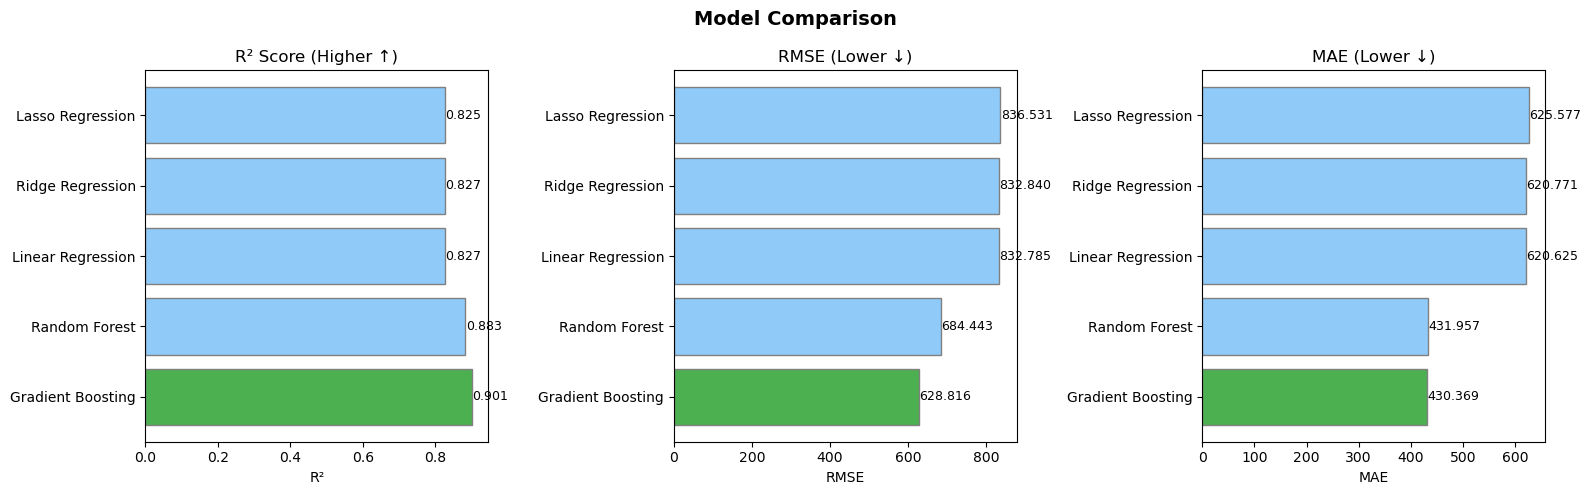

📌 The GREEN bar = Best Model!
            Model       R²       RMSE        MAE
Gradient Boosting 0.901391 628.816213 430.369199
    Random Forest 0.883173 684.443305 431.957279
Linear Regression 0.827045 832.784518 620.625091
 Ridge Regression 0.827022 832.840426 620.771276
 Lasso Regression 0.825485 836.530695 625.576509


In [21]:
# Bar chart comparison
results_df = pd.DataFrame([{'Model': r['name'], 'R²': r['r2'], 'RMSE': r['rmse'], 'MAE': r['mae']} for r in results])
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4CAF50' if i == 0 else '#90CAF9' for i in range(len(results_df))]

for ax, metric, title in zip(axes, ['R²', 'RMSE', 'MAE'], ['R² Score (Higher ↑)', 'RMSE (Lower ↓)', 'MAE (Lower ↓)']):
    bars = ax.barh(results_df['Model'], results_df[metric], color=colors, edgecolor='grey')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(metric)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_width() + 0.001 * results_df[metric].max(), bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print('📌 The GREEN bar = Best Model!')
print(results_df.to_string(index=False))

🏆 Best Model: Gradient Boosting
   R²:   0.9014
   RMSE: 628.8 bikes
   MAE:  430.4 bikes


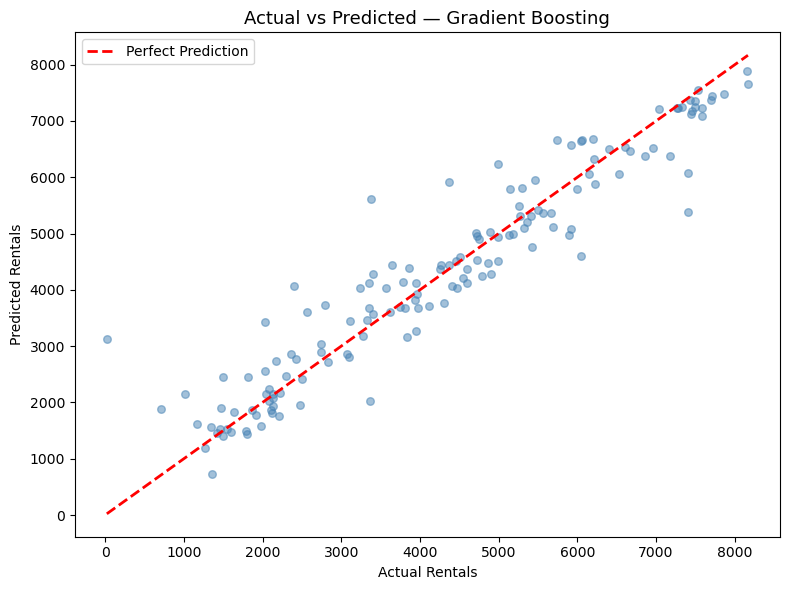

📌 Points close to the red dashed line = accurate predictions!


In [22]:
# Get best model
best = max(results, key=lambda x: x['r2'])
print(f"🏆 Best Model: {best['name']}")
print(f"   R²:   {best['r2']:.4f}")
print(f"   RMSE: {best['rmse']:.1f} bikes")
print(f"   MAE:  {best['mae']:.1f} bikes")

y_pred_best = best['predictions']

# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', s=30)
mn, mx = y_test.min(), y_test.max()
plt.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Rentals')
plt.ylabel('Predicted Rentals')
plt.title(f'Actual vs Predicted — {best["name"]}', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('plot7_actual_vs_pred.png', dpi=100, bbox_inches='tight')
plt.show()
print('📌 Points close to the red dashed line = accurate predictions!')

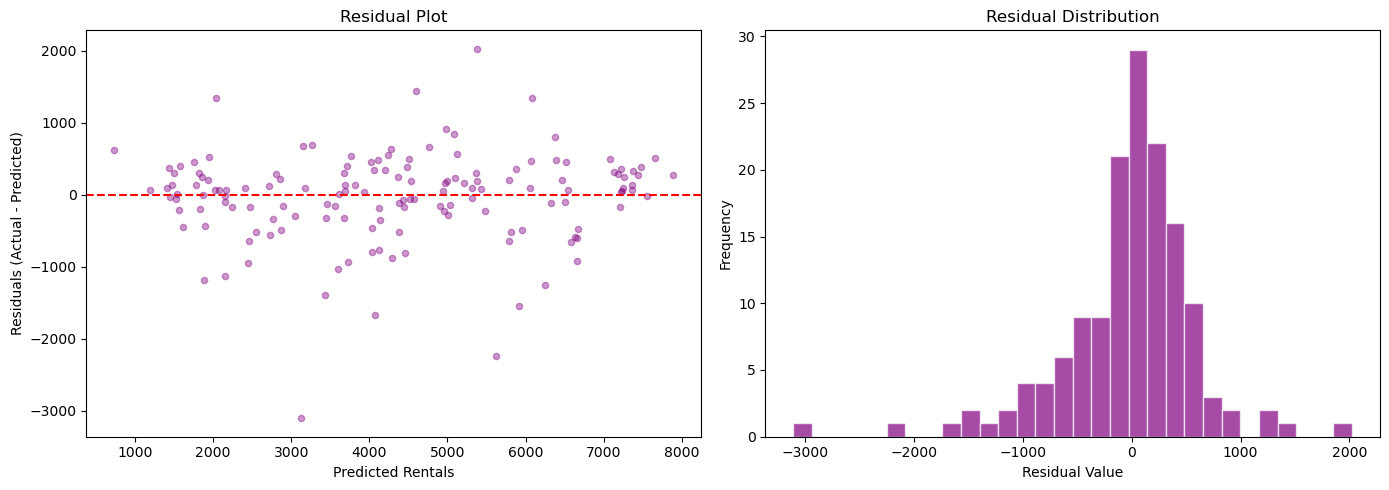

📌 Good model: residuals should be randomly scattered around 0 (no pattern).


In [23]:
# Residual analysis
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.4, color='purple', s=20)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Rentals')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].set_title('Residual Plot')

axes[1].hist(residuals, bins=30, color='purple', edgecolor='white', alpha=0.7)
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('plot8_residuals.png', dpi=100, bbox_inches='tight')
plt.show()
print('📌 Good model: residuals should be randomly scattered around 0 (no pattern).')

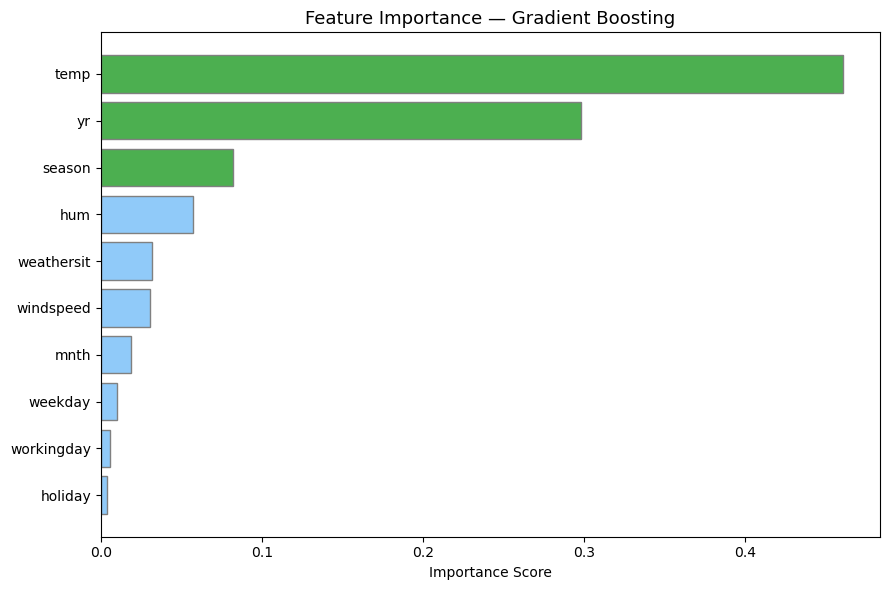

📌 Top Features (GREEN bars):
   temp: 0.4610
   yr: 0.2986
   season: 0.0819


In [24]:
# Get best tree-based model for feature importance
tree_models = [r for r in results if r['name'] in ['Random Forest', 'Gradient Boosting', 'XGBoost']]
best_tree = max(tree_models, key=lambda x: x['r2'])

feat_imp = pd.Series(
    best_tree['model'].feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors_fi = ['#4CAF50' if v >= feat_imp.quantile(0.75) else '#90CAF9' for v in feat_imp]
bars = plt.barh(feat_imp.index, feat_imp.values, color=colors_fi, edgecolor='grey')
plt.title(f'Feature Importance — {best_tree["name"]}', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot9_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('📌 Top Features (GREEN bars):')
top3 = feat_imp.sort_values(ascending=False).head(3)
for f, v in top3.items():
    print(f'   {f}: {v:.4f}')

In [25]:
print('Running 5-Fold Cross-Validation on best model...')
cv_scores = cross_val_score(best_tree['model'], X, y, cv=5, scoring='r2')
print(f'CV R² Scores: {cv_scores.round(4)}')
print(f'Mean R²:  {cv_scores.mean():.4f}')
print(f'Std Dev:  {cv_scores.std():.4f}')
print('\n📌 Low std = model is consistent across different data splits (not overfitting!)')

Running 5-Fold Cross-Validation on best model...
CV R² Scores: [0.3085 0.3769 0.3062 0.4095 0.7496]
Mean R²:  0.4302
Std Dev:  0.1646

📌 Low std = model is consistent across different data splits (not overfitting!)


In [26]:
import joblib

# Save best model and scaler
joblib.dump(best_tree['model'], 'bike_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

print('✅ Saved: bike_model.pkl, scaler.pkl, feature_names.pkl')
print(f'   Model: {best_tree["name"]} | R²: {best_tree["r2"]:.4f}')

✅ Saved: bike_model.pkl, scaler.pkl, feature_names.pkl
   Model: Gradient Boosting | R²: 0.9014
